In [1]:
# 1. IMPORTS AND INITIAL SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, 
                             roc_curve, accuracy_score, precision_score, recall_score, f1_score)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

# Set visualization styles
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
print("✓ All imports completed successfully!")

✓ All imports completed successfully!


In [2]:
# 2. LOAD DATA AND INITIAL EXPLORATION
# Load the dataset
df = pd.read_csv('/Users/sukitharathnayake/CodeRepo/ST4035/Exam-Prep/Data Preprocessing Dataset.csv')

print("Dataset Shape:", df.shape)
print("\n" + "="*80)
print("FIRST FEW ROWS:")
print("="*80)
print(df.head())
print("\n" + "="*80)
print("DATA TYPES:")
print("="*80)
print(df.dtypes)
print("\n" + "="*80)
print("BASIC STATISTICS:")
print("="*80)
print(df.describe())

Dataset Shape: (1000, 14)

FIRST FEW ROWS:
   customer_id        age  annual_income        bmi  credit_score  \
0         1001  43.960570   44299.201364  30.812167    668.954076   
1         1002  36.340828   52395.377860  28.202540    606.037153   
2         1003  45.772262   78604.304326  24.307071    793.340300   
3         1004  56.276358   28719.172062  28.275158    651.740966   
4         1005  35.190160   25903.531196  21.729804    542.993292   

   years_employed education_level employment_status region marital_status  \
0        2.963919     High School         Full-time  South         Single   
1        1.853357       Associate         Full-time  South         Single   
2        3.296726        Bachelor         Full-time  South         Single   
3        1.950945     High School        Unemployed   East        Married   
4        9.130857     High School     Self-employed   West        Widowed   

  loan_purpose customer_satisfaction risk_category  loan_default  
0    Educati

DUPLICATE ANALYSIS:
Total duplicate rows: 0
Rows with duplicate customer_id: 0

MISSING VALUES ANALYSIS:
                                      Column  Missing_Count  \
annual_income                  annual_income             80   
years_employed                years_employed             70   
age                                      age             60   
credit_score                    credit_score             55   
education_level              education_level             50   
bmi                                      bmi             45   
employment_status          employment_status             40   
customer_satisfaction  customer_satisfaction             40   
region                                region             35   
marital_status                marital_status             30   
risk_category                  risk_category             30   
loan_purpose                    loan_purpose             25   

                       Missing_Percentage  
annual_income                  

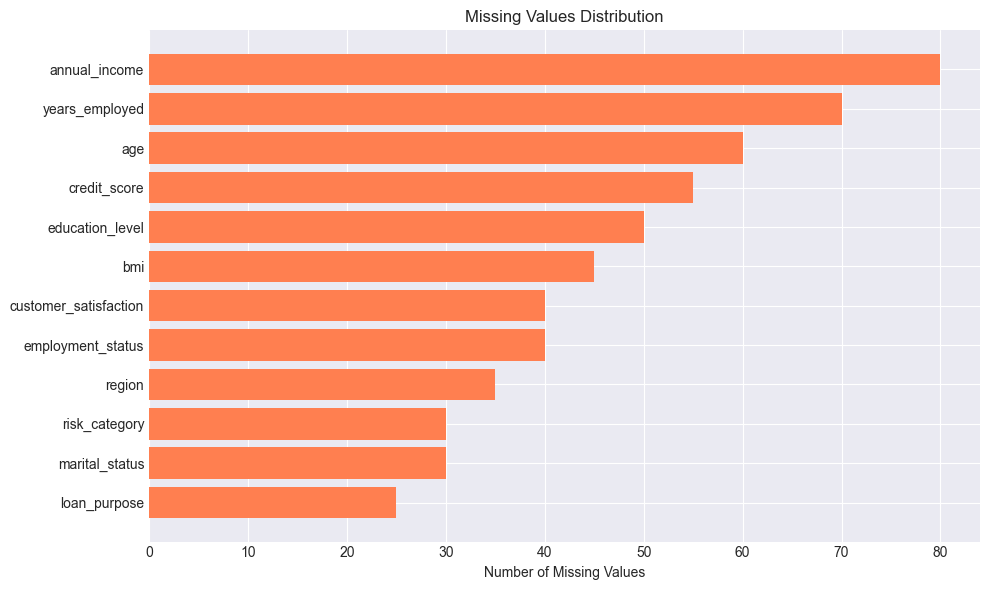

In [3]:
# 3. CHECK FOR DUPLICATES AND MISSING VALUES
print("="*80)
print("DUPLICATE ANALYSIS:")
print("="*80)
print(f"Total duplicate rows: {df.duplicated().sum()}")
print(f"Rows with duplicate customer_id: {df.duplicated(subset=['customer_id']).sum()}")

print("\n" + "="*80)
print("MISSING VALUES ANALYSIS:")
print("="*80)
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_data)

# Visualize missing values
fig, ax = plt.subplots(figsize=(10, 6))
missing_data_sorted = missing_data.sort_values('Missing_Count', ascending=True)
ax.barh(missing_data_sorted['Column'], missing_data_sorted['Missing_Count'], color='coral')
ax.set_xlabel('Number of Missing Values')
ax.set_title('Missing Values Distribution')
plt.tight_layout()
plt.show()

In [4]:
# 4. REMOVE DUPLICATES
print("="*80)
print("REMOVING DUPLICATES:")
print("="*80)
print(f"Original shape: {df.shape}")

# Remove complete duplicates
df = df.drop_duplicates()
print(f"After removing complete duplicates: {df.shape}")

# Remove duplicates based on customer_id (keep first occurrence)
df = df.drop_duplicates(subset=['customer_id'], keep='first')
print(f"After removing duplicate customer_ids: {df.shape}")

print("✓ Duplicates removed successfully!")

REMOVING DUPLICATES:
Original shape: (1000, 14)
After removing complete duplicates: (1000, 14)
After removing duplicate customer_ids: (1000, 14)
✓ Duplicates removed successfully!


In [5]:
# 5. IDENTIFY FEATURE TYPES AND TRAIN-TEST SPLIT
# Identify target variable
target = 'loan_default'
X = df.drop(columns=[target, 'customer_id'])  # Remove target and customer_id
y = df[target]

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("="*80)
print("FEATURE ANALYSIS:")
print("="*80)
print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")
print(f"\nTarget variable distribution:\n{y.value_counts()}")
print(f"Class balance: {(y.value_counts() / len(y) * 100).round(2)}")

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n" + "="*80)
print("TRAIN-TEST SPLIT:")
print("="*80)
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Training set class distribution:\n{y_train.value_counts()}")
print(f"Test set class distribution:\n{y_test.value_counts()}")

FEATURE ANALYSIS:
Categorical columns: ['education_level', 'employment_status', 'region', 'marital_status', 'loan_purpose', 'customer_satisfaction', 'risk_category']
Numerical columns: ['age', 'annual_income', 'bmi', 'credit_score', 'years_employed']

Target variable distribution:
loan_default
0    850
1    150
Name: count, dtype: int64
Class balance: loan_default
0    85.0
1    15.0
Name: count, dtype: float64

TRAIN-TEST SPLIT:
Training set size: (800, 12)
Test set size: (200, 12)
Training set class distribution:
loan_default
0    680
1    120
Name: count, dtype: int64
Test set class distribution:
loan_default
0    170
1     30
Name: count, dtype: int64


In [6]:
# 6. DATA PREPROCESSING: IMPUTATION, STANDARDIZATION, AND ENCODING
print("="*80)
print("DATA PREPROCESSING:")
print("="*80)

# Make copies for transformation
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

# ============= STEP 1: IMPUTATION =============
print("\n1. IMPUTATION:")
print("-" * 40)

# Impute numerical columns with median
imputer_num = SimpleImputer(strategy='median')
X_train_processed[numerical_cols] = imputer_num.fit_transform(X_train_processed[numerical_cols])
X_test_processed[numerical_cols] = imputer_num.transform(X_test_processed[numerical_cols])

# Impute categorical columns with mode
imputer_cat = SimpleImputer(strategy='most_frequent')
X_train_processed[categorical_cols] = imputer_cat.fit_transform(X_train_processed[categorical_cols])
X_test_processed[categorical_cols] = imputer_cat.transform(X_test_processed[categorical_cols])

print(f"Missing values after imputation - Train: {X_train_processed.isnull().sum().sum()}")
print(f"Missing values after imputation - Test: {X_test_processed.isnull().sum().sum()}")

# ============= STEP 2: LABEL ENCODING (for high cardinality features) =============
print("\n2. LABEL ENCODING (for binary categorical):")
print("-" * 40)

label_encoders = {}
binary_categorical_cols = [col for col in categorical_cols if X_train_processed[col].nunique() == 2]

for col in binary_categorical_cols:
    le = LabelEncoder()
    X_train_processed[col] = le.fit_transform(X_train_processed[col])
    X_test_processed[col] = le.transform(X_test_processed[col])
    label_encoders[col] = le
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# ============= STEP 3: ONE-HOT ENCODING (for multi-class categorical) =============
print("\n3. ONE-HOT ENCODING (for multi-class categorical):")
print("-" * 40)

multi_class_categorical_cols = [col for col in categorical_cols if X_train_processed[col].nunique() > 2]

if multi_class_categorical_cols:
    one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
    X_train_one_hot = one_hot_encoder.fit_transform(X_train_processed[multi_class_categorical_cols])
    X_test_one_hot = one_hot_encoder.transform(X_test_processed[multi_class_categorical_cols])
    
    # Get feature names
    feature_names = one_hot_encoder.get_feature_names_out(multi_class_categorical_cols)
    
    # Drop original categorical columns and add one-hot encoded columns
    X_train_processed = X_train_processed.drop(columns=multi_class_categorical_cols)
    X_test_processed = X_test_processed.drop(columns=multi_class_categorical_cols)
    
    X_train_processed = pd.concat([X_train_processed, pd.DataFrame(X_train_one_hot, columns=feature_names, index=X_train_processed.index)], axis=1)
    X_test_processed = pd.concat([X_test_processed, pd.DataFrame(X_test_one_hot, columns=feature_names, index=X_test_processed.index)], axis=1)
    print(f"One-hot encoded columns: {list(feature_names)}")

print(f"\nShape after encoding - Train: {X_train_processed.shape}")
print(f"Shape after encoding - Test: {X_test_processed.shape}")

# ============= STEP 4: STANDARDIZATION =============
print("\n4. STANDARDIZATION:")
print("-" * 40)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed)

# Convert back to DataFrames for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train_processed.columns, index=X_train_processed.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test_processed.columns, index=X_test_processed.index)

print("Standardization completed!")
print(f"Train set mean: {X_train_scaled.mean().mean():.6f}")
print(f"Train set std: {X_train_scaled.std().mean():.6f}")

print("\n✓ Data preprocessing completed successfully!")

DATA PREPROCESSING:

1. IMPUTATION:
----------------------------------------
Missing values after imputation - Train: 0
Missing values after imputation - Test: 0

2. LABEL ENCODING (for binary categorical):
----------------------------------------

3. ONE-HOT ENCODING (for multi-class categorical):
----------------------------------------
One-hot encoded columns: ['education_level_Bachelor', 'education_level_High School', 'education_level_Master', 'education_level_PhD', 'employment_status_Part-time', 'employment_status_Retired', 'employment_status_Self-employed', 'employment_status_Unemployed', 'region_East', 'region_North', 'region_South', 'region_West', 'marital_status_Married', 'marital_status_Single', 'marital_status_Widowed', 'loan_purpose_Car', 'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Medical', 'loan_purpose_Personal', 'customer_satisfaction_Neutral', 'customer_satisfaction_Satisfied', 'customer_satisfaction_Very Dissatisfied', 'customer_satisfaction_Very Sati

EXPLORATORY DATA ANALYSIS - UNIVARIATE:


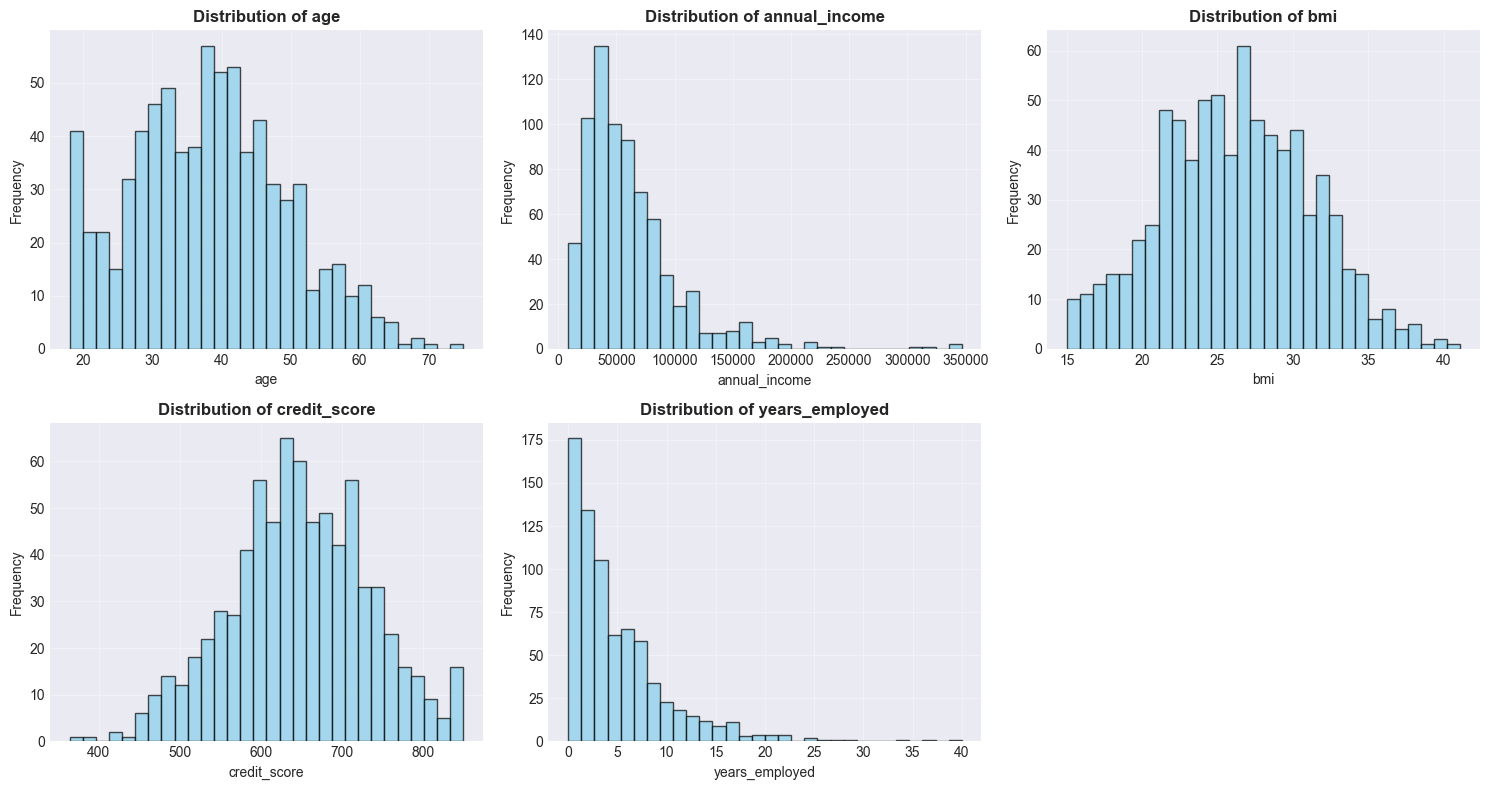


Summary Statistics for Numerical Features:
              age  annual_income         bmi  credit_score  years_employed
count  755.000000     737.000000  764.000000    754.000000      745.000000
mean    38.212741   61763.904722   26.228632    648.104770        5.071506
std     11.209489   42448.914659    4.956551     86.642955        5.212978
min     18.000000    8596.288251   15.000000    364.096657        0.006782
25%     30.109306   34301.313384   22.555436    592.430292        1.422200
50%     38.156023   51003.897777   26.300867    648.330283        3.380539
75%     45.701394   76721.407660   29.794868    708.997417        7.123694
max     75.000000  346727.569550   41.103763    850.000000       40.000000


In [7]:
# 7. EXPLORATORY DATA ANALYSIS (EDA) - UNIVARIATE
print("="*80)
print("EXPLORATORY DATA ANALYSIS - UNIVARIATE:")
print("="*80)

# Get numerical features from original training data for visualization
X_train_original = X_train.copy()
for col in categorical_cols:
    if col in X_train_original.columns:
        X_train_original = X_train_original.drop(columns=[col], errors='ignore')

numerical_features_eda = X_train_original.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Univariate analysis - Histograms and distribution
n_cols = len(numerical_features_eda)
n_rows = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(numerical_features_eda):
    axes[idx].hist(X_train_original[col], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

# Remove extra subplots
for idx in range(len(numerical_features_eda), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# Summary statistics
print("\nSummary Statistics for Numerical Features:")
print(X_train_original[numerical_features_eda].describe())

EXPLORATORY DATA ANALYSIS - BIVARIATE:

Correlation with Target Variable (Loan Default):
age               0.092318
years_employed    0.025105
annual_income    -0.011012
bmi              -0.016725
credit_score     -0.304400
Name: loan_default, dtype: float64


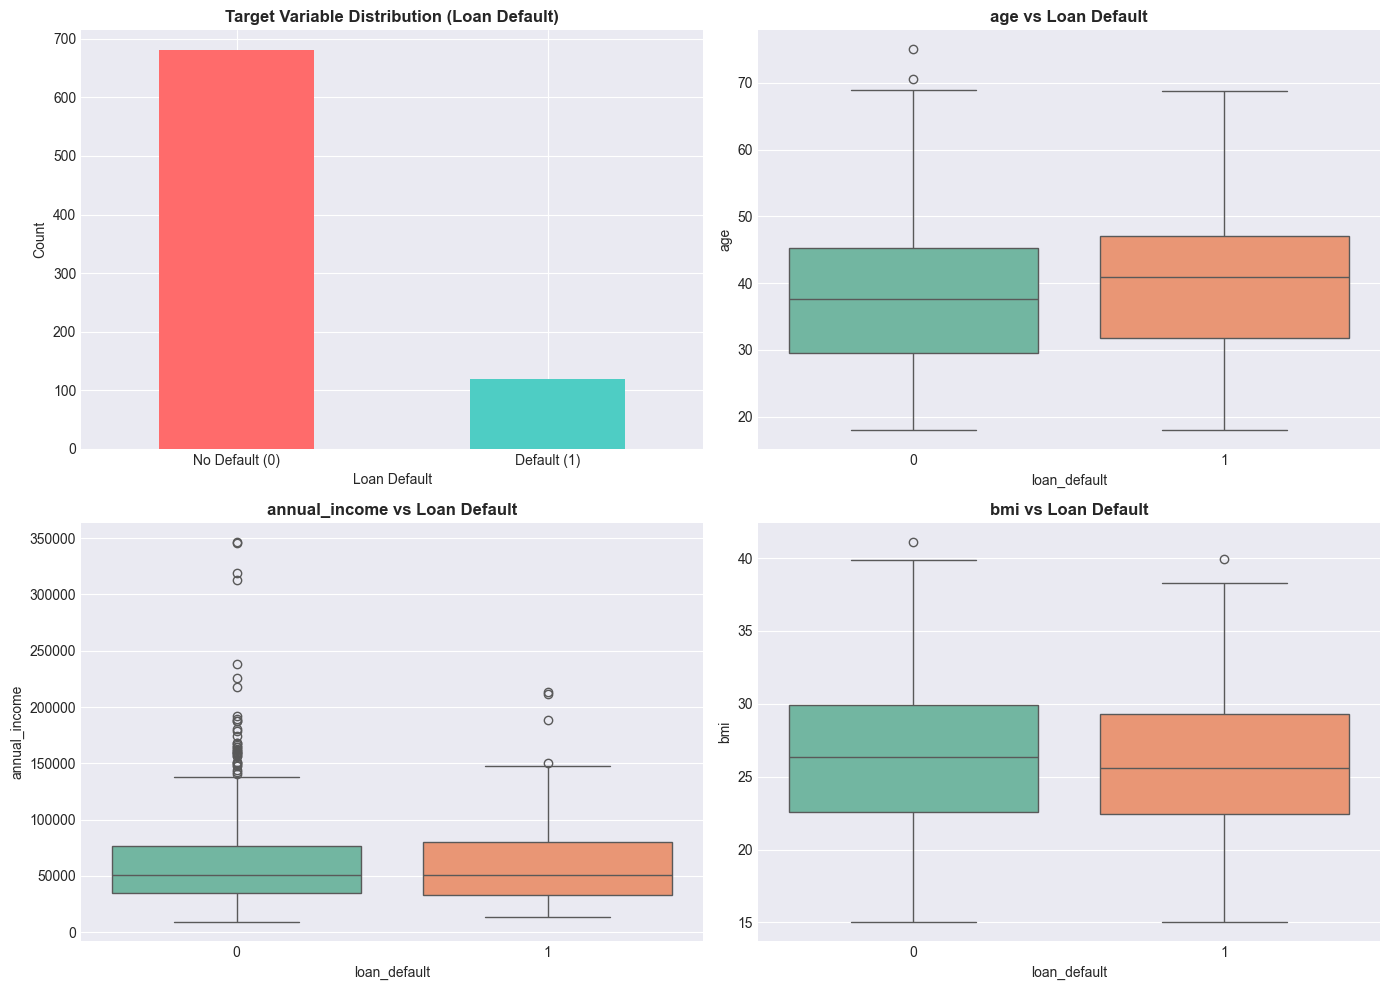

In [8]:
# 8. EXPLORATORY DATA ANALYSIS (EDA) - BIVARIATE
print("="*80)
print("EXPLORATORY DATA ANALYSIS - BIVARIATE:")
print("="*80)

# Bivariate analysis - Relationship with target variable
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target variable distribution
y_train.value_counts().plot(kind='bar', ax=axes[0, 0], color=['#FF6B6B', '#4ECDC4'])
axes[0, 0].set_title('Target Variable Distribution (Loan Default)', fontweight='bold')
axes[0, 0].set_xlabel('Loan Default')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)

# 2. Boxplots for key numerical features vs target
sample_features = numerical_features_eda[:3]
for idx, feature in enumerate(sample_features):
    if idx == 0:
        ax = axes[0, 1]
    else:
        ax = axes[1, idx-1]
    X_train_with_target = X_train_original.copy()
    X_train_with_target['loan_default'] = y_train.values
    sns.boxplot(data=X_train_with_target, x='loan_default', y=feature, ax=ax, palette='Set2')
    ax.set_title(f'{feature} vs Loan Default', fontweight='bold')

# 3. Correlation analysis
correlation_with_target = X_train_with_target[numerical_features_eda + ['loan_default']].corr()['loan_default'].drop('loan_default').sort_values(ascending=False)
print("\nCorrelation with Target Variable (Loan Default):")
print(correlation_with_target)

plt.tight_layout()
plt.show()

EXPLORATORY DATA ANALYSIS - MULTIVARIATE:


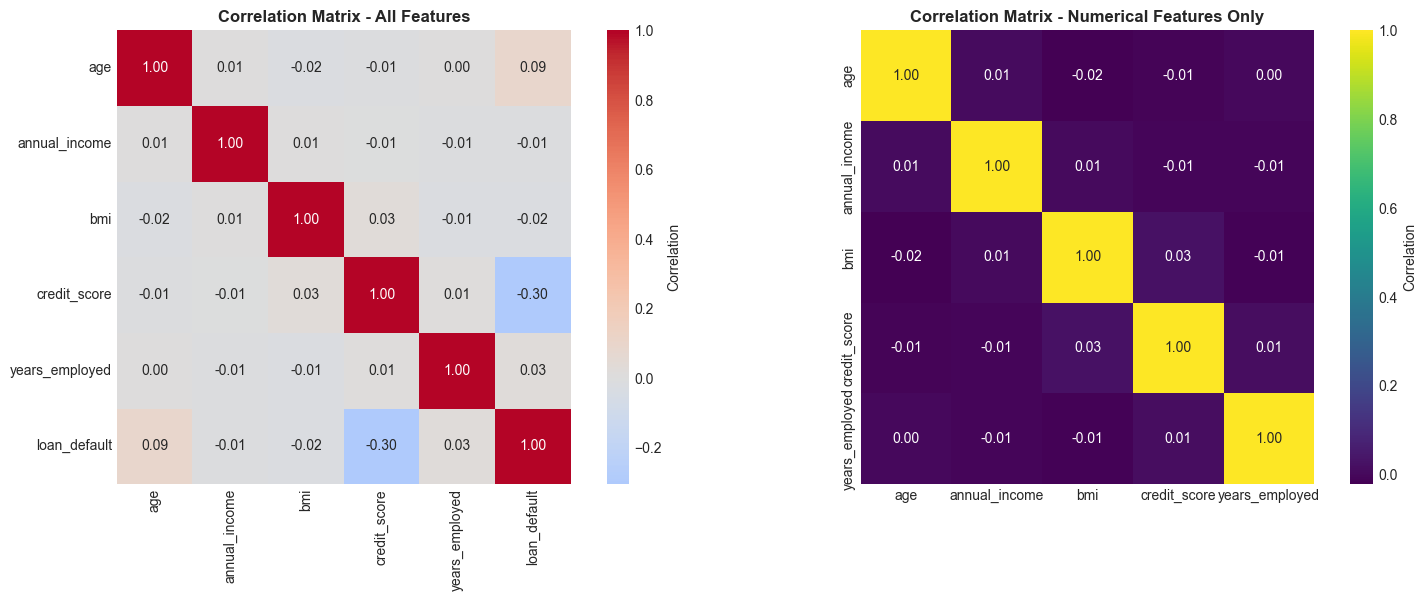


Highly Correlated Feature Pairs (|correlation| > 0.7):
  No pairs with correlation > 0.7 found.


In [9]:
# 9. EXPLORATORY DATA ANALYSIS (EDA) - MULTIVARIATE
print("="*80)
print("EXPLORATORY DATA ANALYSIS - MULTIVARIATE:")
print("="*80)

# Correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full correlation matrix
corr_matrix = X_train_with_target[numerical_features_eda + ['loan_default']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Correlation Matrix - All Features', fontweight='bold')

# Pairwise correlation excluding target
corr_features_only = X_train_with_target[numerical_features_eda].corr()
sns.heatmap(corr_features_only, annot=True, fmt='.2f', cmap='viridis', 
            square=True, ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Correlation Matrix - Numerical Features Only', fontweight='bold')

plt.tight_layout()
plt.show()

# High correlation pairs
print("\nHighly Correlated Feature Pairs (|correlation| > 0.7):")
corr_pairs = []
for i in range(len(corr_features_only.columns)):
    for j in range(i+1, len(corr_features_only.columns)):
        if abs(corr_features_only.iloc[i, j]) > 0.7:
            corr_pairs.append((corr_features_only.columns[i], corr_features_only.columns[j], 
                             corr_features_only.iloc[i, j]))

if corr_pairs:
    for feat1, feat2, corr in sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {feat1} <-> {feat2}: {corr:.3f}")
else:
    print("  No pairs with correlation > 0.7 found.")

In [10]:
# 10. FIT BASIC MACHINE LEARNING MODELS
print("="*80)
print("BASELINE MODEL PERFORMANCE:")
print("="*80)

# Dictionary to store all models for later comparison
models = {}

# Model 1: Logistic Regression (Baseline)
print("\n1. LOGISTIC REGRESSION (Baseline):")
print("-" * 40)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
models['Logistic Regression'] = lr_model

y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f"Train Accuracy: {lr_model.score(X_train_scaled, y_train):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lr):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Test Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"Test F1-Score: {f1_score(y_test, y_pred_lr):.4f}")

# Model 2: Random Forest
print("\n2. RANDOM FOREST:")
print("-" * 40)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
models['Random Forest'] = rf_model

y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print(f"Train Accuracy: {rf_model.score(X_train_scaled, y_train):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")
print(f"Test Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Test Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"Test F1-Score: {f1_score(y_test, y_pred_rf):.4f}")

print("\n✓ Baseline models trained successfully!")

BASELINE MODEL PERFORMANCE:

1. LOGISTIC REGRESSION (Baseline):
----------------------------------------
Train Accuracy: 0.8588
Test Accuracy: 0.8250
Test ROC-AUC: 0.6294
Test Precision: 0.2222
Test Recall: 0.0667
Test F1-Score: 0.1026

2. RANDOM FOREST:
----------------------------------------
Train Accuracy: 1.0000
Test Accuracy: 0.8400
Test ROC-AUC: 0.6117
Test Precision: 0.0000
Test Recall: 0.0000
Test F1-Score: 0.0000

✓ Baseline models trained successfully!


MULTICOLLINEARITY ANALYSIS (VIF):

Variance Inflation Factor (VIF) for All Features:
                                Feature      VIF
        customer_satisfaction_Satisfied 3.072913
          customer_satisfaction_Neutral 2.665714
               education_level_Bachelor 2.397871
   customer_satisfaction_Very Satisfied 2.367550
                 marital_status_Married 2.351217
                  marital_status_Single 2.326038
            education_level_High School 2.248362
                      loan_purpose_Home 2.170920
                       loan_purpose_Car 1.973572
                      risk_category_Low 1.904598
                   risk_category_Medium 1.893043
                           region_South 1.836664
                 loan_purpose_Education 1.794269
                 education_level_Master 1.787976
                  loan_purpose_Personal 1.749357
                            region_West 1.704792
                            region_East 1.672106
                           region

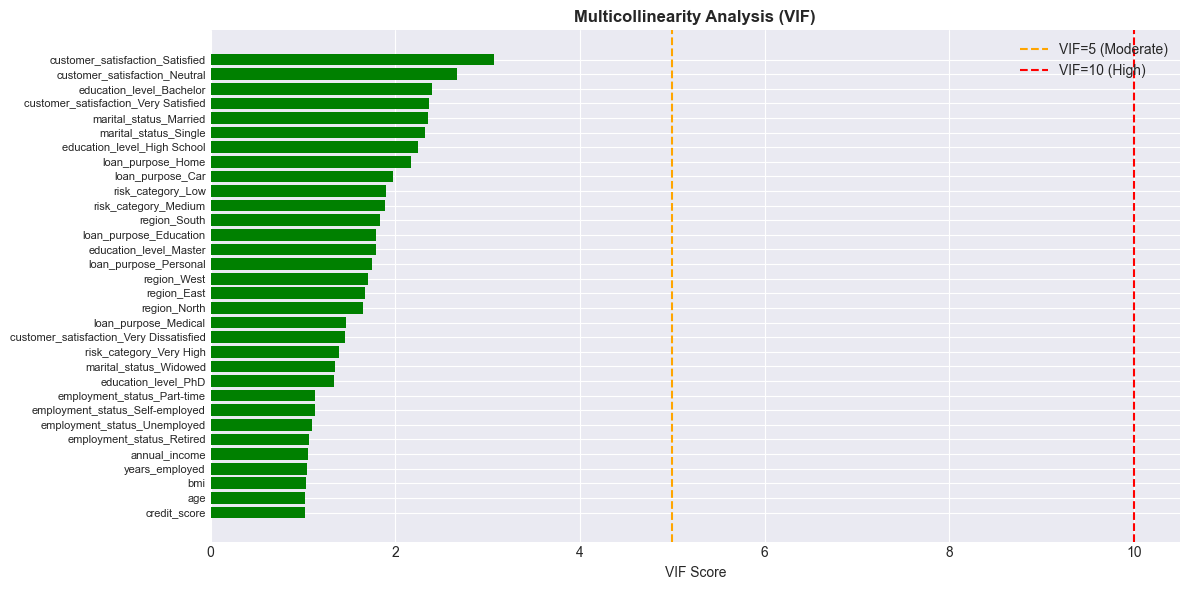

In [11]:
# 11. CHECK FOR MULTICOLLINEARITY (VIF Analysis)
from statsmodels.stats.outliers_influence import variance_inflation_factor

print("="*80)
print("MULTICOLLINEARITY ANALYSIS (VIF):")
print("="*80)

# Calculate VIF for all features
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_scaled.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\nVariance Inflation Factor (VIF) for All Features:")
print(vif_data.to_string(index=False))

# Identify high VIF features (VIF > 10)
high_vif_features = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
print(f"\nFeatures with VIF > 10 (High Multicollinearity): {high_vif_features if high_vif_features else 'None'}")
print(f"Features with VIF > 5 (Moderate Multicollinearity): {vif_data[vif_data['VIF'] > 5]['Feature'].tolist()}")

# Visualize VIF
plt.figure(figsize=(12, 6))
vif_sorted = vif_data.sort_values('VIF')
colors = ['red' if x > 10 else 'orange' if x > 5 else 'green' for x in vif_sorted['VIF']]
plt.barh(range(len(vif_sorted)), vif_sorted['VIF'], color=colors)
plt.yticks(range(len(vif_sorted)), vif_sorted['Feature'], fontsize=8)
plt.xlabel('VIF Score')
plt.title('Multicollinearity Analysis (VIF)', fontweight='bold')
plt.axvline(x=5, color='orange', linestyle='--', label='VIF=5 (Moderate)')
plt.axvline(x=10, color='red', linestyle='--', label='VIF=10 (High)')
plt.legend()
plt.tight_layout()
plt.show()

DATA IMBALANCE ANALYSIS:

Class Distribution in Training Set:
loan_default
0    680
1    120
Name: count, dtype: int64

Class Balance Ratio (0:1): 5.67

Applying SMOTE to balance classes...
Original training set size: (800, 32)
SMOTE training set size: (1360, 32)

Class Distribution After SMOTE:
  Class 0: 680
  Class 1: 680


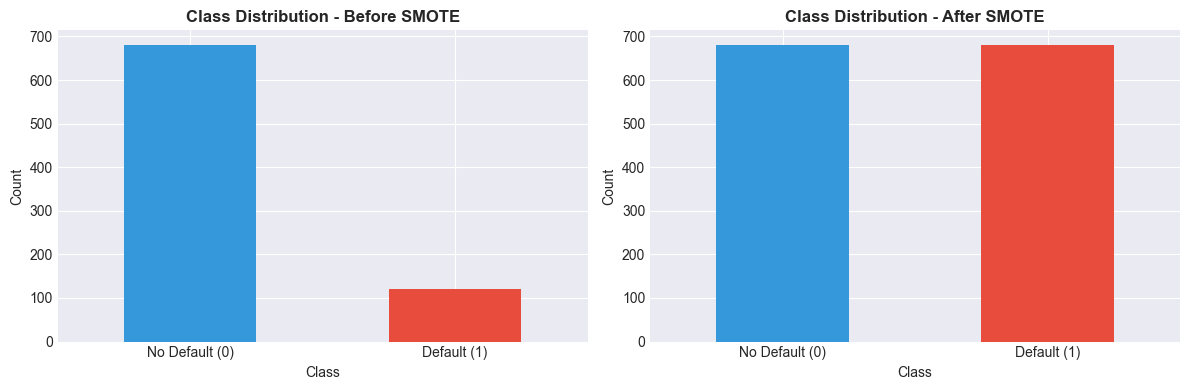


✓ SMOTE applied successfully!


In [12]:
# 12. CHECK FOR AND REMEDY DATA IMBALANCE
print("="*80)
print("DATA IMBALANCE ANALYSIS:")
print("="*80)

# Check class imbalance
print("\nClass Distribution in Training Set:")
class_counts = y_train.value_counts().sort_index()
print(class_counts)
print(f"\nClass Balance Ratio (0:1): {class_counts[0]/class_counts[1]:.2f}")

# Visualize imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before SMOTE
y_train.value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Class Distribution - Before SMOTE', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)

# Apply SMOTE (Synthetic Minority Oversampling Technique)
print("\nApplying SMOTE to balance classes...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original training set size: {X_train_scaled.shape}")
print(f"SMOTE training set size: {X_train_smote.shape}")
print(f"\nClass Distribution After SMOTE:")
unique, counts = np.unique(y_train_smote, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c}")

# Plot after SMOTE
y_train_smote_series = pd.Series(y_train_smote)
y_train_smote_series.value_counts().plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c'])
axes[1].set_title('Class Distribution - After SMOTE', fontweight='bold')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['No Default (0)', 'Default (1)'], rotation=0)

plt.tight_layout()
plt.show()

print("\n✓ SMOTE applied successfully!")

CROSS-VALIDATION ANALYSIS:

Logistic Regression:
----------------------------------------
Accuracy - Mean: 0.7331 (+/- 0.0159)
Precision - Mean: 0.7232 (+/- 0.0177)
Recall - Mean: 0.7559 (+/- 0.0170)
F1-Score - Mean: 0.7391 (+/- 0.0148)
ROC-AUC - Mean: 0.7917 (+/- 0.0158)

Random Forest:
----------------------------------------
Accuracy - Mean: 0.9199 (+/- 0.0105)
Precision - Mean: 0.9443 (+/- 0.0169)
Recall - Mean: 0.8926 (+/- 0.0151)
F1-Score - Mean: 0.9176 (+/- 0.0108)
ROC-AUC - Mean: 0.9753 (+/- 0.0089)


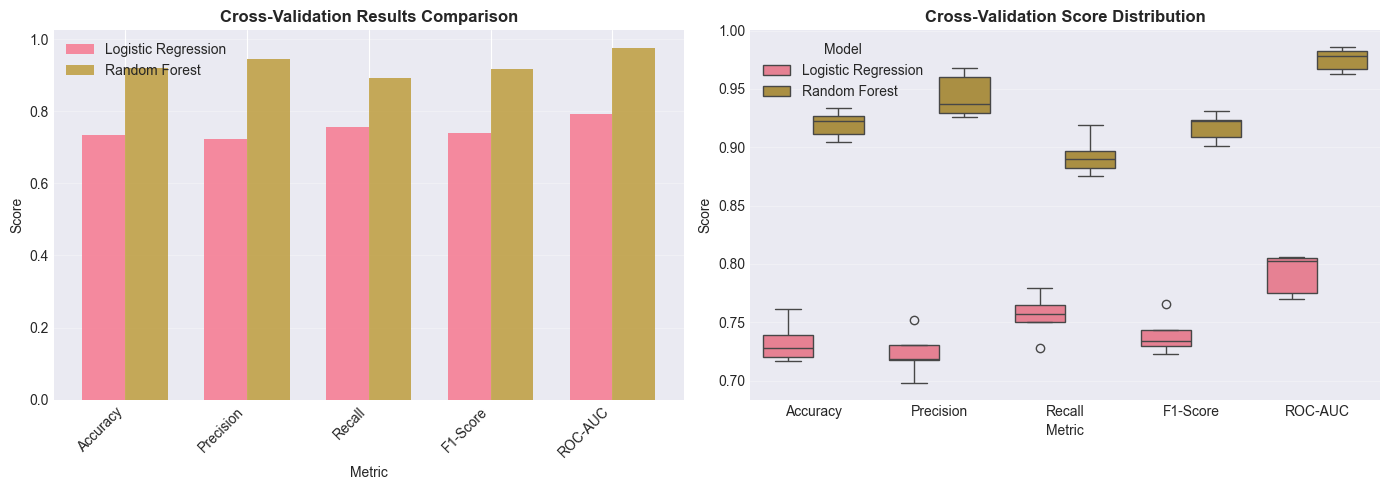

In [13]:
# 13. CROSS-VALIDATION
from sklearn.model_selection import StratifiedKFold

print("="*80)
print("CROSS-VALIDATION ANALYSIS:")
print("="*80)

# Use stratified k-fold for binary classification
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Models to cross-validate
cv_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

cv_results = {}

for model_name, model in cv_models.items():
    print(f"\n{model_name}:")
    print("-" * 40)
    
    # Cross-validate with multiple metrics
    cv_scores = cross_validate(model, X_train_smote, y_train_smote, cv=skf,
                               scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc'],
                               n_jobs=-1)
    
    cv_results[model_name] = cv_scores
    
    print(f"Accuracy - Mean: {cv_scores['test_accuracy'].mean():.4f} (+/- {cv_scores['test_accuracy'].std():.4f})")
    print(f"Precision - Mean: {cv_scores['test_precision'].mean():.4f} (+/- {cv_scores['test_precision'].std():.4f})")
    print(f"Recall - Mean: {cv_scores['test_recall'].mean():.4f} (+/- {cv_scores['test_recall'].std():.4f})")
    print(f"F1-Score - Mean: {cv_scores['test_f1'].mean():.4f} (+/- {cv_scores['test_f1'].std():.4f})")
    print(f"ROC-AUC - Mean: {cv_scores['test_roc_auc'].mean():.4f} (+/- {cv_scores['test_roc_auc'].std():.4f})")

# Visualize cross-validation results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

# Bar plot
x_pos = np.arange(len(metrics))
width = 0.35

for idx, (model_name, scores) in enumerate(cv_results.items()):
    means = [scores[f'test_{m}'].mean() for m in metrics]
    stds = [scores[f'test_{m}'].std() for m in metrics]
    axes[0].bar(x_pos + idx*width, means, width, label=model_name, alpha=0.8)

axes[0].set_xlabel('Metric')
axes[0].set_ylabel('Score')
axes[0].set_title('Cross-Validation Results Comparison', fontweight='bold')
axes[0].set_xticks(x_pos + width / 2)
axes[0].set_xticklabels(metric_labels, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Box plot
cv_data_list = []
for model_name, scores in cv_results.items():
    for metric, label in zip(metrics, metric_labels):
        for score in scores[f'test_{metric}']:
            cv_data_list.append({'Model': model_name, 'Metric': label, 'Score': score})

cv_df = pd.DataFrame(cv_data_list)
sns.boxplot(data=cv_df, x='Metric', y='Score', hue='Model', ax=axes[1])
axes[1].set_title('Cross-Validation Score Distribution', fontweight='bold')
axes[1].set_ylabel('Score')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [14]:
# 14. REGULARIZATION AND HYPERPARAMETER TUNING
print("="*80)
print("REGULARIZATION AND HYPERPARAMETER TUNING:")
print("="*80)

# ============= LOGISTIC REGRESSION WITH REGULARIZATION =============
print("\n1. LOGISTIC REGRESSION - GridSearchCV:")
print("-" * 40)

lr_params = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['saga', 'liblinear']
}

lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), 
                       lr_params, cv=5, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train_smote, y_train_smote)

print(f"Best Parameters: {lr_grid.best_params_}")
print(f"Best CV ROC-AUC Score: {lr_grid.best_score_:.4f}")

best_lr_model = lr_grid.best_estimator_
models['LR (Tuned)'] = best_lr_model

y_pred_lr_tuned = best_lr_model.predict(X_test_scaled)
y_pred_proba_lr_tuned = best_lr_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nTest Set Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_lr_tuned):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_lr_tuned):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_lr_tuned):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_lr_tuned):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_pred_proba_lr_tuned):.4f}")

# ============= RIDGE AND LASSO REGRESSION =============
print("\n2. RIDGE REGRESSION - GridSearchCV:")
print("-" * 40)

ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
ridge_grid.fit(X_train_smote, y_train_smote)

print(f"Best Alpha: {ridge_grid.best_params_['alpha']}")
print(f"Best CV Score: {abs(ridge_grid.best_score_):.4f}")

print("\n3. LASSO REGRESSION - GridSearchCV:")
print("-" * 40)

lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000, random_state=42), 
                          lasso_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
lasso_grid.fit(X_train_smote, y_train_smote)

print(f"Best Alpha: {lasso_grid.best_params_['alpha']}")
print(f"Best CV Score: {abs(lasso_grid.best_score_):.4f}")

# ============= RANDOM FOREST HYPERPARAMETER TUNING =============
print("\n4. RANDOM FOREST - GridSearchCV:")
print("-" * 40)

rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1), 
                       rf_params, cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train_smote, y_train_smote)

print(f"Best Parameters: {rf_grid.best_params_}")
print(f"Best CV ROC-AUC Score: {rf_grid.best_score_:.4f}")

best_rf_model = rf_grid.best_estimator_
models['RF (Tuned)'] = best_rf_model

y_pred_rf_tuned = best_rf_model.predict(X_test_scaled)
y_pred_proba_rf_tuned = best_rf_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nTest Set Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_rf_tuned):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_rf_tuned):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_rf_tuned):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf_tuned):.4f}")

# ============= GRADIENT BOOSTING =============
print("\n5. GRADIENT BOOSTING - GridSearchCV:")
print("-" * 40)

gb_params = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
}

gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=42), 
                       gb_params, cv=5, scoring='roc_auc', n_jobs=-1)
gb_grid.fit(X_train_smote, y_train_smote)

print(f"Best Parameters: {gb_grid.best_params_}")
print(f"Best CV ROC-AUC Score: {gb_grid.best_score_:.4f}")

best_gb_model = gb_grid.best_estimator_
models['Gradient Boosting (Tuned)'] = best_gb_model

y_pred_gb_tuned = best_gb_model.predict(X_test_scaled)
y_pred_proba_gb_tuned = best_gb_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nTest Set Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_gb_tuned):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_gb_tuned):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_gb_tuned):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_gb_tuned):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_pred_proba_gb_tuned):.4f}")

print("\n✓ Hyperparameter tuning completed!")

REGULARIZATION AND HYPERPARAMETER TUNING:

1. LOGISTIC REGRESSION - GridSearchCV:
----------------------------------------
Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'saga'}
Best CV ROC-AUC Score: 0.7965

Test Set Performance:
  Accuracy: 0.6200
  Precision: 0.1974
  Recall: 0.5000
  F1-Score: 0.2830
  ROC-AUC: 0.5971

2. RIDGE REGRESSION - GridSearchCV:
----------------------------------------
Best Alpha: 10
Best CV Score: 0.2406

3. LASSO REGRESSION - GridSearchCV:
----------------------------------------
Best Alpha: 0.001
Best CV Score: 0.2403

4. RANDOM FOREST - GridSearchCV:
----------------------------------------
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV ROC-AUC Score: 0.9843

Test Set Performance:
  Accuracy: 0.8000
  Precision: 0.2222
  Recall: 0.1333
  F1-Score: 0.1667
  ROC-AUC: 0.6032

5. GRADIENT BOOSTING - GridSearchCV:
----------------------------------------
Best Parameters: {'learning_r

MODEL COMPARISON AND EVALUATION METRICS:

COMPREHENSIVE MODEL COMPARISON:
                           Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                                    
Logistic Regression           0.825     0.2222  0.0667    0.1026   0.6294
Random Forest                 0.840     0.0000  0.0000    0.0000   0.6117
LR (Tuned)                    0.620     0.1974  0.5000    0.2830   0.5971
RF (Tuned)                    0.800     0.2222  0.1333    0.1667   0.6032
Gradient Boosting (Tuned)     0.780     0.2500  0.2333    0.2414   0.5751

BEST MODELS BY METRIC:
Accuracy: Random Forest (0.8400)
Precision: Gradient Boosting (Tuned) (0.2500)
Recall: LR (Tuned) (0.5000)
F1-Score: LR (Tuned) (0.2830)
ROC-AUC: Logistic Regression (0.6294)


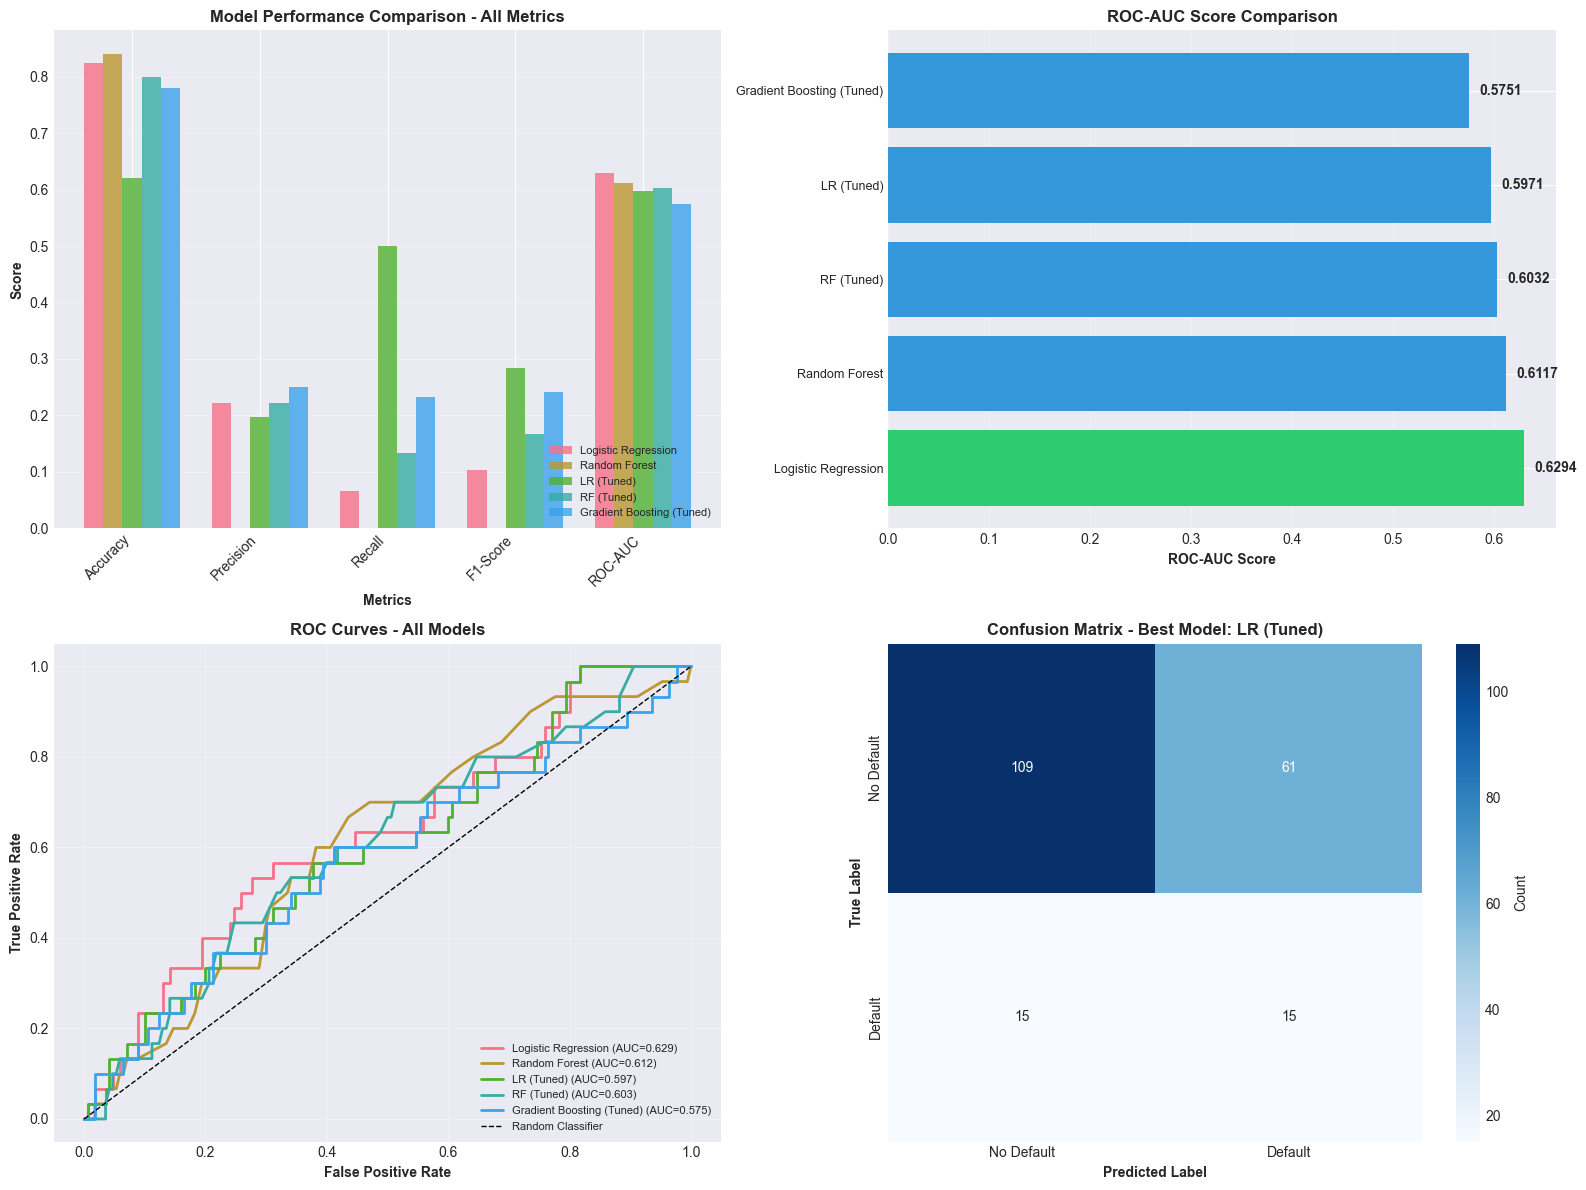


DETAILED EVALUATION - BEST MODEL: LR (Tuned)

Classification Report:
              precision    recall  f1-score   support

  No Default       0.88      0.64      0.74       170
     Default       0.20      0.50      0.28        30

    accuracy                           0.62       200
   macro avg       0.54      0.57      0.51       200
weighted avg       0.78      0.62      0.67       200


Confusion Matrix:
  True Negatives:  109
  False Positives: 61
  False Negatives: 15
  True Positives:  15

Additional Metrics:
  Specificity: 0.6412
  Sensitivity: 0.5000
  False Positive Rate: 0.3588
  False Negative Rate: 0.5000

✓ MODEL ANALYSIS COMPLETED SUCCESSFULLY!


In [15]:
# 15. MODEL COMPARISON AND EVALUATION METRICS
print("="*80)
print("MODEL COMPARISON AND EVALUATION METRICS:")
print("="*80)

# Dictionary to store predictions for all models
all_predictions = {
    'Logistic Regression': (y_pred_lr, y_pred_proba_lr),
    'Random Forest': (y_pred_rf, y_pred_proba_rf),
    'LR (Tuned)': (y_pred_lr_tuned, y_pred_proba_lr_tuned),
    'RF (Tuned)': (y_pred_rf_tuned, y_pred_proba_rf_tuned),
    'Gradient Boosting (Tuned)': (y_pred_gb_tuned, y_pred_proba_gb_tuned),
}

# Create comparison dataframe
comparison_results = []

for model_name, (y_pred, y_pred_proba) in all_predictions.items():
    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba),
    }
    comparison_results.append(results)

comparison_df = pd.DataFrame(comparison_results).set_index('Model').round(4)

print("\n" + "="*80)
print("COMPREHENSIVE MODEL COMPARISON:")
print("="*80)
print(comparison_df)

# Find best model for each metric
print("\n" + "="*80)
print("BEST MODELS BY METRIC:")
print("="*80)
for metric in comparison_df.columns:
    best_model = comparison_df[metric].idxmax()
    best_score = comparison_df[metric].max()
    print(f"{metric}: {best_model} ({best_score:.4f})")

# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Metrics comparison bar plot
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.15

for idx, (model_name, row) in enumerate(comparison_df.iterrows()):
    values = [row[m] for m in metrics]
    axes[0, 0].bar(x + idx*width, values, width, label=model_name, alpha=0.8)

axes[0, 0].set_xlabel('Metrics', fontweight='bold')
axes[0, 0].set_ylabel('Score', fontweight='bold')
axes[0, 0].set_title('Model Performance Comparison - All Metrics', fontweight='bold', fontsize=12)
axes[0, 0].set_xticks(x + width * 2)
axes[0, 0].set_xticklabels(metrics, rotation=45, ha='right')
axes[0, 0].legend(loc='lower right', fontsize=8)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. ROC-AUC Comparison
roc_auc_scores = comparison_df['ROC-AUC'].sort_values(ascending=False)
colors_roc = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(roc_auc_scores))]
axes[0, 1].barh(range(len(roc_auc_scores)), roc_auc_scores.values, color=colors_roc)
axes[0, 1].set_yticks(range(len(roc_auc_scores)))
axes[0, 1].set_yticklabels(roc_auc_scores.index, fontsize=9)
axes[0, 1].set_xlabel('ROC-AUC Score', fontweight='bold')
axes[0, 1].set_title('ROC-AUC Score Comparison', fontweight='bold', fontsize=12)
axes[0, 1].grid(True, alpha=0.3, axis='x')
for i, v in enumerate(roc_auc_scores.values):
    axes[0, 1].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

# 3. ROC Curves
for model_name, (y_pred, y_pred_proba) in all_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    axes[1, 0].plot(fpr, tpr, label=f'{model_name} (AUC={roc_auc:.3f})', linewidth=2)

axes[1, 0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1, 0].set_xlabel('False Positive Rate', fontweight='bold')
axes[1, 0].set_ylabel('True Positive Rate', fontweight='bold')
axes[1, 0].set_title('ROC Curves - All Models', fontweight='bold', fontsize=12)
axes[1, 0].legend(loc='lower right', fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# 4. Confusion Matrix for best model
best_model_name = comparison_df['F1-Score'].idxmax()
y_pred_best, _ = all_predictions[best_model_name]
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1], 
            xticklabels=['No Default', 'Default'], 
            yticklabels=['No Default', 'Default'],
            cbar_kws={'label': 'Count'})
axes[1, 1].set_title(f'Confusion Matrix - Best Model: {best_model_name}', fontweight='bold', fontsize=12)
axes[1, 1].set_ylabel('True Label', fontweight='bold')
axes[1, 1].set_xlabel('Predicted Label', fontweight='bold')

plt.tight_layout()
plt.show()

# ============= DETAILED EVALUATION FOR BEST MODEL =============
print("\n" + "="*80)
print(f"DETAILED EVALUATION - BEST MODEL: {best_model_name}")
print("="*80)

y_pred_best, y_pred_proba_best = all_predictions[best_model_name]

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=['No Default', 'Default']))

print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0, 0]}")
print(f"  False Positives: {cm[0, 1]}")
print(f"  False Negatives: {cm[1, 0]}")
print(f"  True Positives:  {cm[1, 1]}")

print(f"\nAdditional Metrics:")
specificity = cm[0, 0] / (cm[0, 0] + cm[0, 1])
sensitivity = cm[1, 1] / (cm[1, 0] + cm[1, 1])
print(f"  Specificity: {specificity:.4f}")
print(f"  Sensitivity: {sensitivity:.4f}")
print(f"  False Positive Rate: {1 - specificity:.4f}")
print(f"  False Negative Rate: {1 - sensitivity:.4f}")

print("\n" + "="*80)
print("✓ MODEL ANALYSIS COMPLETED SUCCESSFULLY!")
print("="*80)